## Simple Linear Regression

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
## read the dataset
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

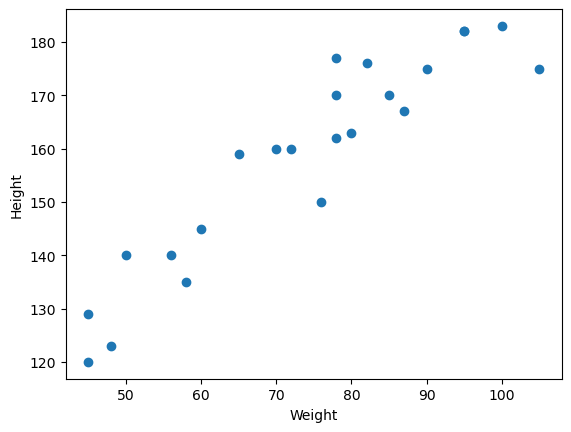

In [16]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [17]:
## divide dataset into dependent and independent features
X=df[['Weight']]
y=df['Height']

In [18]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)
## for training dataset X_train is the independent feature and y_train is the dependent feature

In [19]:
X.shape,y.shape

((23, 1), (23,))

In [20]:
X_train.shape,X_test.shape

((18, 1), (5, 1))

In [21]:
y_train.shape,y_test.shape

((18,), (5,))

In [22]:
## Standardizing the dataset train independent data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [23]:
X_train.head()

,Weight
12,105
1,58
13,100
5,78
2,48


In [24]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

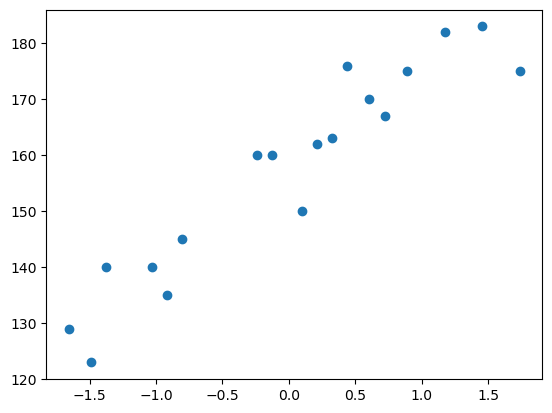

In [25]:
plt.scatter(X_train,y_train)

In [26]:
## Train the Simple Linear Regression Model
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()

In [27]:
regressor.fit(X_train,y_train)

LinearRegression()

In [28]:
print("Slope/coefficient of weight : ",regressor.coef_)
print("Intercept : ",regressor.intercept_)

Slope/coefficient of weight :  [17.03440872]
Intercept :  157.5


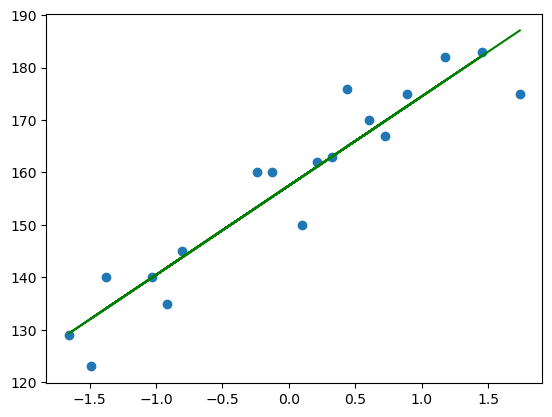

In [29]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),'g')

In [30]:
y_pred_test=regressor.predict(X_test)

In [31]:
y_pred_test,y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

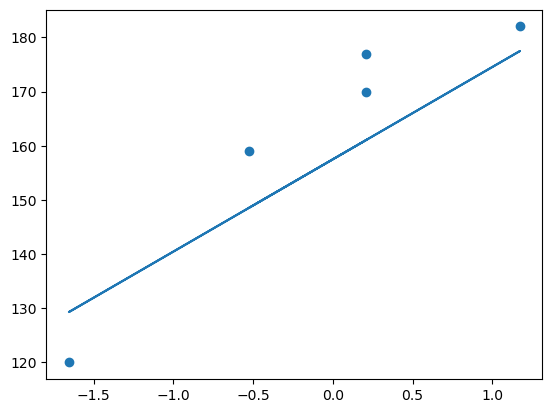

In [32]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regressor.predict(X_test))

## Performance metrics
## MSE,MAE,RMSE
## R square and adjusted R square

In [33]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [34]:
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print("MSE : ",mse)
print("MAE : ",mae)
print("RMSE : ",rmse)

MSE :  109.77592599051654
MAE :  9.822657814519227
RMSE :  10.477400726827076


In [35]:
from sklearn.metrics import r2_score

In [37]:
score=r2_score(y_test,y_pred_test)

In [38]:
score

0.7769869860423441

In [39]:
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231254

In [40]:
regressor

LinearRegression()

In [41]:
## new data point weight is 80
scaled_weight=scaler.transform([[80]])
scaled_weight

C:\Users\Santosh\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [45]:
print("Height prediction weight 80 kg is",regressor.predict([scaled_weight[0]]))

Height prediction weight 80 kg is [163.01076266]


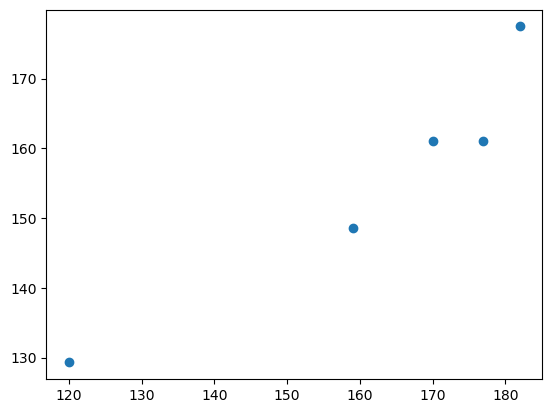

In [46]:
## Assumptions
## plot a scatter plot for predction 
plt.scatter(y_test,y_pred_test)

In [47]:
## Residuals
residuals=y_test-y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

C:\Users\Santosh\AppData\Local\Temp\ipykernel_2712\3282999518.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='Height', ylabel='Density'>

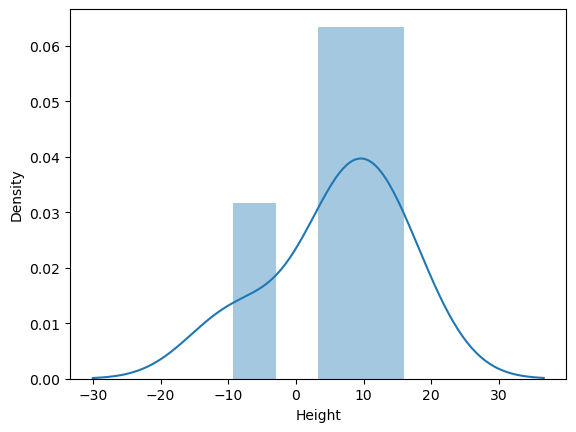

In [56]:
##plot this residuals 
import seaborn as sns
sns.distplot(residuals,kde=True)

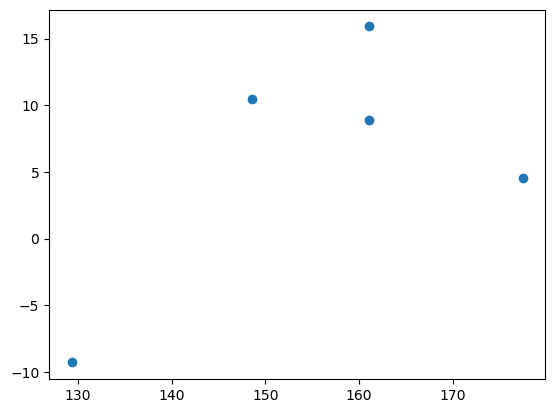

In [57]:
## scatter plot wrt prediction and residuals
## uniform distribution
plt.scatter(y_pred_test,residuals)